# CAMDA 2023 MetaSUB Microbiome ML Training — Kaggle Notebook

This notebook trains machine-learning models using the CAMDA 2023 MetaSUB dataset from:

`https://github.com/ccm-bioinfo/cambda2023/tree/main/data`

Main experiment:

- **Dataset:** `camda_relative.csv`
- **Input X:** microbial relative abundance features
- **Target y:** `City`
- **Models:** Random Forest, Linear SVM, Logistic Regression, XGBoost
- **Evaluation:** train/test metrics, 5-fold cross-validation, classification report, confusion matrix
- **Explainability:** feature importance and optional SHAP

Before running in Kaggle, turn on internet:

`Notebook Settings → Internet → ON`


## Step 1 — Install required libraries

In [1]:
!pip install -q xgboost shap joblib

## Step 2 — Import libraries and set paths

In [2]:
import os
import warnings
import urllib.request
import shutil
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_STATE = 42

DATA_DIR = "/kaggle/working/camda2023_data"
OUT_DIR = "/kaggle/working/microbiome_ml_results"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("Data directory:", DATA_DIR)
print("Output directory:", OUT_DIR)

Data directory: /kaggle/working/camda2023_data
Output directory: /kaggle/working/microbiome_ml_results


## Step 3 — Download dataset files from GitHub

The GitHub folder page is not directly used for training. We download the raw files.

In [3]:
urls = {
    "camda_relative.csv": "https://raw.githubusercontent.com/ccm-bioinfo/cambda2023/main/data/camda_relative.csv",
    "metadata_completos.csv": "https://raw.githubusercontent.com/ccm-bioinfo/cambda2023/main/data/metadata_completos.csv",
    "amr_counts_complement_20230621.tsv": "https://raw.githubusercontent.com/ccm-bioinfo/cambda2023/main/data/amr_counts_complement_20230621.tsv"
}

for fname, url in urls.items():
    out_path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(out_path):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(url, out_path)
    else:
        print(f"{fname} already exists.")

print("\nDownload completed.")
print(os.listdir(DATA_DIR))


Download completed.
['amr_counts_complement_20230621.tsv', 'metadata_completos.csv', 'camda_relative.csv']


## Step 4 — Load and inspect the dataset

In [4]:
feature_path = os.path.join(DATA_DIR, "camda_relative.csv")
metadata_path = os.path.join(DATA_DIR, "metadata_completos.csv")
amr_path = os.path.join(DATA_DIR, "amr_counts_complement_20230621.tsv")

df = pd.read_csv(feature_path)
metadata = pd.read_csv(metadata_path)

print("camda_relative.csv shape:", df.shape)
print("metadata_completos.csv shape:", metadata.shape)

print("\nFirst 15 columns of camda_relative.csv:")
print(df.columns[:15].tolist())

print("\nPreview of camda_relative.csv:")
display(df.head())

print("\nPreview of metadata_completos.csv:")
display(metadata.head())

camda_relative.csv shape: (286, 18296)
metadata_completos.csv shape: (289, 12)

First 15 columns of camda_relative.csv:
['ID', 'ID_city', 'City', 'Latitude', 'Longitude', 'Climate', 'Year', '468', '469', '28090', '2708348', '2853158', '2725684', '2563897', '1879049']

Preview of camda_relative.csv:


/tmp/ipykernel_58/2543845482.py:5: DtypeWarning: Columns (3363,3878) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(feature_path)


,ID,ID_city,City,Latitude,Longitude,Climate,Year,468,469,28090,...,1146874,1519389,12480,1131,2886895,546184,12330,1922682,1513254,1922952
0,CAMDA23_MetaSUB_gCSD16_AKL_10,AKL,Auckland,-36.75,174.75,Cfb,2016,0.048249,10.696605,14.560432,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CAMDA23_MetaSUB_gCSD16_AKL_11,AKL,Auckland,-36.75,174.75,Cfb,2016,0.038155,0.527739,0.041985,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CAMDA23_MetaSUB_gCSD16_AKL_12,AKL,Auckland,-36.75,174.75,Cfb,2016,0.002185,0.234138,0.051282,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CAMDA23_MetaSUB_gCSD16_AKL_13,AKL,Auckland,-36.75,174.75,Cfb,2016,0.000142,0.014304,0.010763,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CAMDA23_MetaSUB_gCSD16_AKL_14,AKL,Auckland,-36.75,174.75,Cfb,2016,0.002103,0.061997,0.079509,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Preview of metadata_completos.csv:


,sample_id,Experiment,Assay Type,seq_type,Organism,plant_part,host_name,latitude,longitude,state,country,continent
0,SRR10127267,SRX6855687,WGS,Shotgun,plant metagenome,Phylosphere,Agave Tequilana,21.7658,-100.163,Jalisco,Mexico,North America
1,SRR10127271,SRX6855691,WGS,Shotgun,plant metagenome,Phylosphere,Myrtillocactus Geometrizans,21.7658,-100.163,Guanajuato,Mexico,North America
2,SRR10591223,SRX7271075,WGA,16S,rhizosphere metagenome,Rhizosphere,Cephalocereus polylophus,20.5900,-100.380,Queretaro,Mexico,North America
3,SRR10591224,SRX7271074,WGA,16S,rhizosphere metagenome,Rhizosphere,Cephalocereus polylophus,20.5900,-100.380,Queretaro,Mexico,North America
4,SRR10591225,SRX7271073,WGA,16S,rhizosphere metagenome,Rhizosphere,Cephalocereus polylophus,20.5900,-100.380,Queretaro,Mexico,North America


## Step 5 — Prepare X and y correctly

Important correction:

`camda_relative.csv` is already arranged as:

- rows = samples
- columns = metadata + microbial features

So do **not** transpose it.

In [5]:
target_col = "City"

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found. Available columns: {df.columns[:20].tolist()}")

# Metadata columns are not microbial features.
metadata_cols = [
    "ID",
    "ID_city",
    "City",
    "Latitude",
    "Longitude",
    "Climate",
    "Year"
]

# Keep only metadata columns that actually exist.
metadata_cols = [col for col in metadata_cols if col in df.columns]

print("Metadata columns found:")
print(metadata_cols)

# Microbial feature columns = all columns except metadata columns.
feature_cols = [col for col in df.columns if col not in metadata_cols]

print("\nNumber of microbial feature columns:", len(feature_cols))
print("First 10 microbial feature columns:")
print(feature_cols[:10])

# X = microbial relative abundance features.
X = df[feature_cols].copy()

# y = city label.
y = df[target_col].copy()

# Convert all features to numeric.
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

# Remove rows with missing target labels.
valid_rows = y.notna()
X = X.loc[valid_rows].reset_index(drop=True)
y = y.loc[valid_rows].reset_index(drop=True)

print("\nPrepared dataset before filtering:")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution before filtering:")
print(y.value_counts())

Metadata columns found:
['ID', 'ID_city', 'City', 'Latitude', 'Longitude', 'Climate', 'Year']

Number of microbial feature columns: 18289
First 10 microbial feature columns:
['468', '469', '28090', '2708348', '2853158', '2725684', '2563897', '1879049', '2773709', '2079596']

Prepared dataset before filtering:
X shape: (286, 18289)
y shape: (286,)

Class distribution before filtering:
City
Denver           44
Doha             27
Tokyo            25
Sao Paulo        25
New York City    20
Ilorin           18
Sacramento       16
Vienna           16
San Antonio      16
Zurich           16
Lisbon           15
Berlin           15
Auckland         14
Baltimore        13
Mineapolis        6
Name: count, dtype: int64


## Step 6 — Clean labels, filter weak classes, remove rare/constant features, and encode labels

This step fixes the warnings you saw during cross-validation:

- constant feature warnings
- invalid division warnings from `f_classif`
- ill-defined precision warnings caused by tiny classes

In [6]:
# -------------------------------
# 6.1 Remove city classes with very few samples
# -------------------------------

# For 5-fold CV, each class should have enough samples.
# 10 is safer than 5 for this dataset.
min_samples_per_class = 10

class_counts = y.value_counts()
keep_classes = class_counts[class_counts >= min_samples_per_class].index

X = X[y.isin(keep_classes)].copy()
y = y[y.isin(keep_classes)].copy()

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

print("After class filtering:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", y.nunique())
print("\nClass distribution:")
print(y.value_counts())

# -------------------------------
# 6.2 Remove rare microbial features
# -------------------------------

# Keep features that appear in at least 3 samples.
nonzero_count = (X > 0).sum(axis=0)
keep_features = nonzero_count[nonzero_count >= 3].index

X = X[keep_features].copy()

print("\nAfter rare-feature filtering:")
print("X shape:", X.shape)

# -------------------------------
# 6.3 Remove globally constant features
# -------------------------------

print("\nBefore removing constant features:", X.shape)

global_variance_filter = VarianceThreshold(threshold=0.0)
X_filtered = global_variance_filter.fit_transform(X)

kept_feature_names = X.columns[global_variance_filter.get_support()]
X = pd.DataFrame(X_filtered, columns=kept_feature_names)

print("After removing constant features:", X.shape)

# -------------------------------
# 6.4 Log transform microbiome abundance data
# -------------------------------

# Microbiome abundance data are sparse and skewed.
X = np.log1p(X)
X = pd.DataFrame(X, columns=kept_feature_names)

print("\nAfter log transformation:")
print("X shape:", X.shape)

# -------------------------------
# 6.5 Encode city labels
# -------------------------------

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = pd.DataFrame({
    "class_id": range(len(label_encoder.classes_)),
    "city_label": label_encoder.classes_
})

print("\nLabel mapping:")
display(label_mapping)

label_mapping.to_csv(os.path.join(OUT_DIR, "label_mapping.csv"), index=False)

After class filtering:
X shape: (280, 18289)
y shape: (280,)
Number of classes: 14

Class distribution:
City
Denver           44
Doha             27
Sao Paulo        25
Tokyo            25
New York City    20
Ilorin           18
Vienna           16
San Antonio      16
Zurich           16
Sacramento       16
Berlin           15
Lisbon           15
Auckland         14
Baltimore        13
Name: count, dtype: int64

After rare-feature filtering:
X shape: (280, 15244)

Before removing constant features: (280, 15244)
After removing constant features: (280, 15244)

After log transformation:
X shape: (280, 15244)

Label mapping:


,class_id,city_label
0,0,Auckland
1,1,Baltimore
2,2,Berlin
3,3,Denver
4,4,Doha
5,5,Ilorin
6,6,Lisbon
7,7,New York City
8,8,Sacramento
9,9,San Antonio


## Step 7 — Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (224, 15244)
Testing samples: (56, 15244)


## Step 8 — Define robust models

The pipeline uses:

1. `VarianceThreshold` to remove constant features inside each fold.
2. `SelectKBest` to select the top microbial features.
3. ML classifier.

This makes cross-validation cleaner.

In [8]:
# Select top features to reduce noise and speed up training.
# Keep this lower if Kaggle is slow.
k_features = min(3000, X.shape[1])

models = {
    "RandomForest": Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("select", SelectKBest(score_func=f_classif, k=k_features)),
        ("model", RandomForestClassifier(
            n_estimators=500,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]),

    "LinearSVM": Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("select", SelectKBest(score_func=f_classif, k=k_features)),
        ("scaler", StandardScaler(with_mean=False)),
        ("model", SVC(
            kernel="linear",
            C=1,
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),

    "LogisticRegression": Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("select", SelectKBest(score_func=f_classif, k=k_features)),
        ("scaler", StandardScaler(with_mean=False)),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

    "XGBoost": Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("select", SelectKBest(score_func=f_classif, k=k_features)),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="mlogloss",
            random_state=RANDOM_STATE
        ))
    ])
}

print("Models ready.")
print("Number of selected features:", k_features)

Models ready.
Number of selected features: 3000


## Step 9 — Train/test evaluation

In [9]:
train_test_results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro", zero_division=0)
    precision = precision_score(y_test, preds, average="macro", zero_division=0)
    recall = recall_score(y_test, preds, average="macro", zero_division=0)

    train_test_results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro_F1": f1,
        "Macro_Precision": precision,
        "Macro_Recall": recall
    })

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall: {recall:.4f}")

train_test_results_df = pd.DataFrame(train_test_results).sort_values("Macro_F1", ascending=False)

print("\nTrain/test model comparison:")
display(train_test_results_df)

train_test_results_df.to_csv(
    os.path.join(OUT_DIR, "train_test_model_results.csv"),
    index=False
)


Training RandomForest...
Accuracy: 0.8571
Macro F1: 0.8503
Macro Precision: 0.9024
Macro Recall: 0.8440

Training LinearSVM...
Accuracy: 0.8036
Macro F1: 0.8053
Macro Precision: 0.8716
Macro Recall: 0.7786

Training LogisticRegression...
Accuracy: 0.8393
Macro F1: 0.8215
Macro Precision: 0.8546
Macro Recall: 0.8262

Training XGBoost...
Accuracy: 0.9107
Macro F1: 0.8960
Macro Precision: 0.9430
Macro Recall: 0.8905

Train/test model comparison:


,Model,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
3,XGBoost,0.910714,0.896001,0.942965,0.890476
0,RandomForest,0.857143,0.850304,0.902381,0.844048
2,LogisticRegression,0.839286,0.821506,0.854592,0.826190
1,LinearSVM,0.803571,0.805272,0.871599,0.778571


## Step 10 — 5-fold cross-validation

Use this table as the main result in your paper.

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0)
}

cv_results = []

for name, model in models.items():
    print(f"\nCross-validating {name}...")

    scores = cross_validate(
        model,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    cv_results.append({
        "Model": name,
        "Accuracy_Mean": scores["test_accuracy"].mean(),
        "Accuracy_Std": scores["test_accuracy"].std(),
        "Macro_F1_Mean": scores["test_f1_macro"].mean(),
        "Macro_F1_Std": scores["test_f1_macro"].std(),
        "Macro_Precision_Mean": scores["test_precision_macro"].mean(),
        "Macro_Precision_Std": scores["test_precision_macro"].std(),
        "Macro_Recall_Mean": scores["test_recall_macro"].mean(),
        "Macro_Recall_Std": scores["test_recall_macro"].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    "Macro_F1_Mean",
    ascending=False
)

print("\n5-fold cross-validation results:")
display(cv_results_df)

cv_results_df.to_csv(
    os.path.join(OUT_DIR, "cross_validation_results.csv"),
    index=False
)


Cross-validating RandomForest...

Cross-validating LinearSVM...

Cross-validating LogisticRegression...

Cross-validating XGBoost...

5-fold cross-validation results:


,Model,Accuracy_Mean,Accuracy_Std,Macro_F1_Mean,Macro_F1_Std,Macro_Precision_Mean,Macro_Precision_Std,Macro_Recall_Mean,Macro_Recall_Std
3,XGBoost,0.885714,0.043154,0.874095,0.058147,0.907424,0.053773,0.870476,0.059220
2,LogisticRegression,0.828571,0.058248,0.816660,0.077929,0.848821,0.078513,0.823889,0.072464
0,RandomForest,0.807143,0.070891,0.794049,0.076421,0.837782,0.054865,0.798254,0.079808
1,LinearSVM,0.764286,0.038132,0.741024,0.045873,0.792589,0.040032,0.746270,0.046743


## Step 11 — Train the best final model

In [11]:
best_model_name = cv_results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model based on CV Macro F1:", best_model_name)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

joblib.dump(best_model, os.path.join(OUT_DIR, f"best_model_{best_model_name}.joblib"))
joblib.dump(label_encoder, os.path.join(OUT_DIR, "label_encoder.joblib"))

print("Best model saved.")

Best model based on CV Macro F1: XGBoost
Best model saved.


## Step 12 — Classification report

In [12]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

print("Classification report for:", best_model_name)
display(report_df)

report_df.to_csv(
    os.path.join(OUT_DIR, f"classification_report_{best_model_name}.csv")
)

Classification report for: XGBoost


,precision,recall,f1-score,support
Auckland,1.000000,1.000000,1.000000,3.000000
Baltimore,1.000000,1.000000,1.000000,3.000000
Berlin,1.000000,0.666667,0.800000,3.000000
Denver,0.818182,1.000000,0.900000,9.000000
Doha,1.000000,0.800000,0.888889,5.000000
Ilorin,0.800000,1.000000,0.888889,4.000000
Lisbon,1.000000,1.000000,1.000000,3.000000
New York City,1.000000,1.000000,1.000000,4.000000
Sacramento,1.000000,1.000000,1.000000,3.000000
San Antonio,1.000000,0.333333,0.500000,3.000000


## Step 13 — Confusion matrix

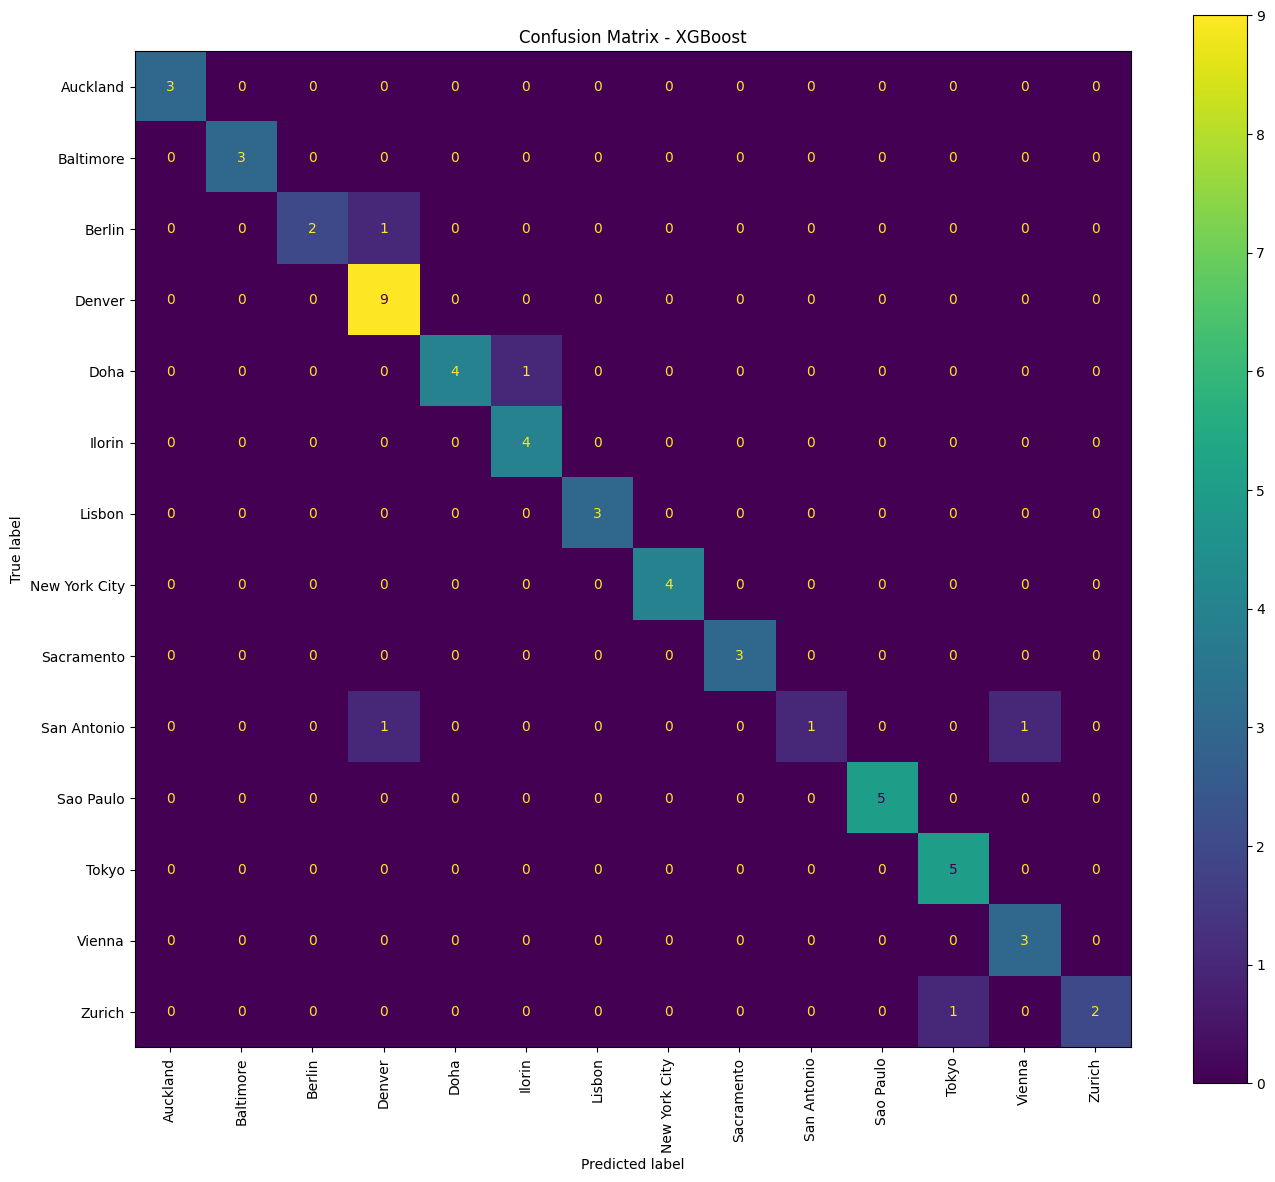

Saved confusion matrix: /kaggle/working/microbiome_ml_results/confusion_matrix_XGBoost.png


In [13]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(ax=ax, xticks_rotation=90, values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()

confusion_path = os.path.join(OUT_DIR, f"confusion_matrix_{best_model_name}.png")
plt.savefig(confusion_path, dpi=300)
plt.show()

print("Saved confusion matrix:", confusion_path)

## Step 14 — Feature importance

This works directly for Random Forest and XGBoost.

Top 30 microbial features:


,Microbial_Feature,Importance
2968,2845395,0.026869
1620,2879846,0.021897
2121,2760705,0.018523
1405,2831000,0.014847
84,249188,0.014655
219,44255,0.013523
2967,287412,0.013290
2673,1851167,0.013014
40,2714945,0.009877
2966,2845413,0.009250


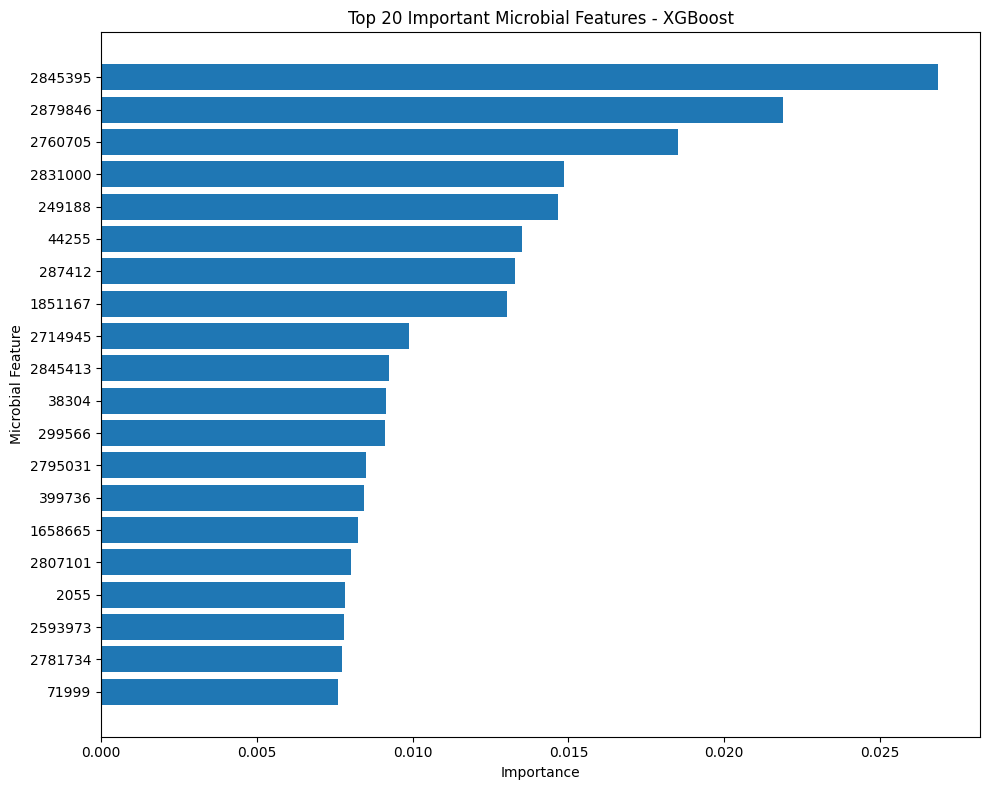

Saved feature importance CSV: /kaggle/working/microbiome_ml_results/feature_importance_XGBoost.csv
Saved feature importance figure: /kaggle/working/microbiome_ml_results/top20_feature_importance_XGBoost.png


In [14]:
pipeline = best_model

# Step names:
# variance -> select -> optional scaler -> model
variance_step = pipeline.named_steps["variance"]
selector_step = pipeline.named_steps["select"]
final_model = pipeline.named_steps["model"]

# Reconstruct feature names after variance and selection.
features_after_variance = X.columns[variance_step.get_support()]
selected_features = features_after_variance[selector_step.get_support()]

if hasattr(final_model, "feature_importances_"):
    importances = final_model.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Microbial_Feature": selected_features,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("Top 30 microbial features:")
    display(feature_importance_df.head(30))

    importance_csv = os.path.join(OUT_DIR, f"feature_importance_{best_model_name}.csv")
    feature_importance_df.to_csv(importance_csv, index=False)

    top20 = feature_importance_df.head(20).iloc[::-1]

    plt.figure(figsize=(10, 8))
    plt.barh(top20["Microbial_Feature"], top20["Importance"])
    plt.xlabel("Importance")
    plt.ylabel("Microbial Feature")
    plt.title(f"Top 20 Important Microbial Features - {best_model_name}")
    plt.tight_layout()

    importance_png = os.path.join(OUT_DIR, f"top20_feature_importance_{best_model_name}.png")
    plt.savefig(importance_png, dpi=300)
    plt.show()

    print("Saved feature importance CSV:", importance_csv)
    print("Saved feature importance figure:", importance_png)

else:
    print(f"{best_model_name} does not provide direct feature_importances_.")
    print("Use SHAP or model coefficients for explanation.")

## Step 15 — Optional SHAP explainability

Run this only if your best model is Random Forest or XGBoost. If it is slow, skip this step.

Computing SHAP for: XGBoost


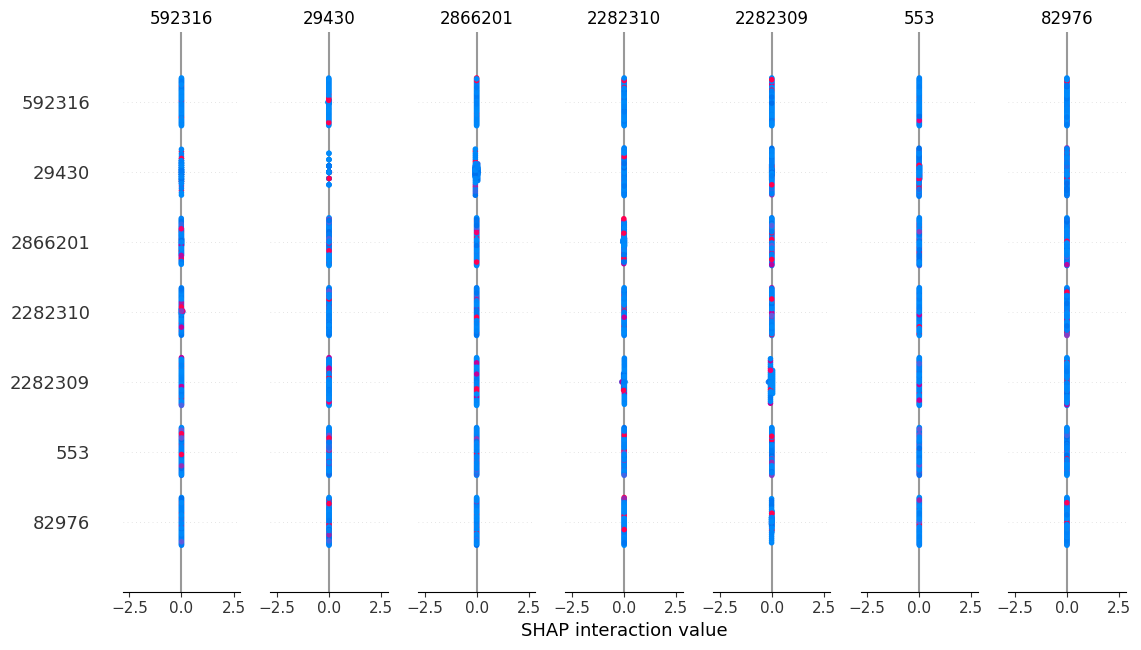

Saved SHAP summary: /kaggle/working/microbiome_ml_results/shap_summary_XGBoost.png


In [15]:
try:
    import shap

    if best_model_name in ["RandomForest", "XGBoost"]:
        print("Computing SHAP for:", best_model_name)

        # Transform X_test through variance and select steps.
        X_test_var = variance_step.transform(X_test)
        X_test_selected = selector_step.transform(X_test_var)

        sample_size = min(100, X_test_selected.shape[0])
        X_shap = X_test_selected[:sample_size]

        explainer = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(X_shap)

        # For multiclass, shap_values may be a list.
        if isinstance(shap_values, list):
            shap.summary_plot(
                shap_values[0],
                X_shap,
                feature_names=selected_features,
                show=False
            )
        else:
            shap.summary_plot(
                shap_values,
                X_shap,
                feature_names=selected_features,
                show=False
            )

        plt.tight_layout()
        shap_path = os.path.join(OUT_DIR, f"shap_summary_{best_model_name}.png")
        plt.savefig(shap_path, dpi=300)
        plt.show()

        print("Saved SHAP summary:", shap_path)

    else:
        print("SHAP TreeExplainer is recommended when the best model is RandomForest or XGBoost.")
        print("Your best model is:", best_model_name)

except Exception as e:
    print("SHAP step skipped because of an error:")
    print(e)

## Step 16 — Optional AMR file inspection

This does not train the AMR model yet. It only checks the AMR dataset for your second experiment.

In [16]:
try:
    amr_df = pd.read_csv(amr_path, sep="\t")
    print("AMR dataset shape:", amr_df.shape)
    print("AMR columns preview:")
    print(amr_df.columns[:10].tolist())
    display(amr_df.head())
except Exception as e:
    print("Could not read AMR file:")
    print(e)

AMR dataset shape: (10, 506)
AMR columns preview:
['db', 'kdpe', 'sila', 'mrka', 'ant2ia', 'flia', 'flii', 'kpne', 'oqxb24', 'teml100']


,db,kdpe,sila,mrka,ant2ia,flia,flii,kpne,oqxb24,teml100,...,tle1,pmrl,iucd,vasetssk,aada5,allc,chuu,senb,pata,arr
0,BAL_En.fasta,0,0,0,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,DEN_En.fasta,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,MIN_En.fasta,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,NYC_En.fasta,0,39,2,0,7,25,1,15,0,...,0,0,7,0,0,0,0,0,0,0
4,NYC_Es.fasta,0,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Step 17 — Zip and download results

After running this cell, download `microbiome_ml_results.zip` from Kaggle output files.

In [17]:
zip_base = "/kaggle/working/microbiome_ml_results"
zip_path = zip_base + ".zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(zip_base, "zip", OUT_DIR)

print("Results zipped at:", zip_path)
print("\nFiles inside result folder:")
print(os.listdir(OUT_DIR))

Results zipped at: /kaggle/working/microbiome_ml_results.zip

Files inside result folder:
['best_model_XGBoost.joblib', 'top20_feature_importance_XGBoost.png', 'shap_summary_XGBoost.png', 'label_mapping.csv', 'feature_importance_XGBoost.csv', 'confusion_matrix_XGBoost.png', 'label_encoder.joblib', 'train_test_model_results.csv', 'cross_validation_results.csv', 'classification_report_XGBoost.csv']


## Suggested methodology text for your paper

You can write:

> This study used the CAMDA 2023 MetaSUB urban metagenomic dataset to evaluate the feasibility of machine-learning-based microbiome monitoring for critical infrastructure. Microbial relative abundance profiles were used as input features, while city labels were used as the sample-origin classification target. After removing low-sample classes, rare microbial features, and constant features, the abundance matrix was log-transformed and encoded for supervised learning. Random Forest, Linear Support Vector Machine, Logistic Regression, and XGBoost models were trained and evaluated using stratified 5-fold cross-validation. Performance was assessed using accuracy, macro precision, macro recall, macro F1-score, confusion matrix analysis, and feature-importance-based interpretation.
